<div align="center">

<h1> <b> IMPLEMENTACIÓN DE LAS FORMULACIONES LAGRANGIANA Y HAMILTONIANA EN LA SOLUCIÓN DE CIRCUITOS ELÉCTRICOS </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Vergara Restrepo Cristian <br>
Mendoza Montes Bernardo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  
</i></h3>
</div>

---


# Planteamiento del problema

Las formulaciones lagrangiana y hamiltoniana surgieron para resolver problemas mecánicos, pero su generalidad conceptual respecto al enfoque newtoniano les permite abordar sistemas físicos ajenos a la mecánica con modificaciones relativamente sencillas. Los circuitos eléctricos son uno de esos sistemas: al construir un lagrangiano equivalente, el formalismo ofrece una descripción geométrica y energética de la dinámica del circuito que complementa la descripción local que dan las leyes de Kirchhoff (Goldstein et al., 2001; Devoret, 1997).

# Objetivos

* Establecer cómo usar las formulaciones lagrangiana y hamiltoniana para resolver circuitos eléctricos.
* Resolver circuitos eléctricos típicos y analizar las diferencias conceptuales con las leyes de Kirchhoff.
* Graficar los diagramas de fase de los circuitos.
* Emplear los desarrollos anteriores para introducir la cuantización de circuitos y explorar la juntura de Josephson.

# Modelo físico

Antes de resolver cualquier circuito es necesario fijar las coordenadas generalizadas y el papel que juega cada elemento del circuito dentro del formalismo de Lagrange y Hamilton.

La coordenada generalizada deja de ser la posición de una partícula y pasa a ser la carga del circuito $q$; su derivada temporal, la "velocidad" generalizada, es la corriente: $\dot q = I$. El análogo de la masa es la inductancia $L$, y en lugar de energía cinética se habla de la energía almacenada en el inductor, $T$:

$$
T = \frac{1}{2}LI^2 = \frac{1}{2}L\dot{q}^2
$$

El voltaje y la resistencia del circuito se introducen como fuerzas generalizadas no conservativas. En particular, la resistencia $R$ se modela mediante una función de Rayleigh, apropiada para fuerzas disipativas proporcionales a la velocidad generalizada:

$$
\mathcal{R} = \frac{1}{2}RI^2 = \frac{1}{2}R\dot{q}^2
$$

La capacitancia $C$ desempeña el papel de la constante de Hooke y actúa como el resorte del circuito, responsable de las oscilaciones. $U$ denota la energía almacenada en el capacitor:

$$
U = \frac{1}{2}\frac{q^2}{C}
$$

# Lagrangiano y solución de circuitos típicos

El primer circuito que vale la pena revisar es el LC (inductor-capacitor). Su lagrangiano es

$$
\mathcal{L} = \frac{1}{2}L\dot{q}^2 - \frac{1}{2}\frac{q^2}{C}
$$

y al aplicar las ecuaciones de Euler-Lagrange se obtiene la ecuación estándar de un oscilador armónico con frecuencia natural $\omega = 1/\sqrt{LC}$ (la derivación completa está en la sección de derivaciones más adelante):

$$
\ddot{q} + \frac{q}{LC} = 0
$$

El circuito LCR (inductor-capacitor-resistencia) comparte el mismo lagrangiano; la diferencia aparece al incluir la función de Rayleigh en las ecuaciones de Euler-Lagrange, lo que produce la ecuación de un oscilador amortiguado:

$$
\ddot{q} + \frac{R}{L}\dot{q} + \frac{q}{LC} = 0
$$

Esta es la solución conocida del circuito LCR. El enfoque lagrangiano se vuelve especialmente útil al resolver circuitos acoplados, donde escribir directamente las ecuaciones de Kirchhoff para cada malla resulta más engorroso que construir un único lagrangiano del sistema.

# Transición al formalismo hamiltoniano y retrato de fase

Una vez obtenidas las ecuaciones de movimiento a partir del lagrangiano, el siguiente paso es pasar al formalismo hamiltoniano. Mientras que el lagrangiano describe el sistema en términos de posición y velocidad, el hamiltoniano lo hace en términos de posición y momento conjugado, lo que facilita el estudio de la conservación de energía y la construcción del espacio de fases.

### 1. Momento conjugado

Siguiendo la analogía en la que la corriente $\dot q$ equivale a la velocidad y la inductancia $L$ a la masa, el momento conjugado $p$ (que representa físicamente el flujo magnético en el inductor) se define como

$$p = \frac{\partial \mathcal{L}}{\partial \dot{q}} = L\dot{q}.$$

### 2. Construcción del hamiltoniano

La transformada de Legendre lleva del lagrangiano al hamiltoniano. Con $T = \tfrac12 L\dot q^2$ y $U = \tfrac12 q^2/C$, el hamiltoniano $H$ representa la energía total del sistema:

$$H(q, p) = p\dot{q} - \mathcal{L} = \frac{p^2}{2L} + \frac{q^2}{2C}.$$

### 3. Ecuaciones de Hamilton con disipación

En el circuito LCR la naturaleza disipativa de $R$ se incorpora mediante la función de Rayleigh. Las ecuaciones de evolución de primer orden quedan:

1. Evolución de la carga: $\displaystyle \dot{q} = \frac{\partial H}{\partial p} = \frac{p}{L}$
2. Evolución del momento: $\displaystyle \dot{p} = -\frac{\partial H}{\partial q} - \frac{\partial \mathcal{R}}{\partial \dot{q}} = -\frac{q}{C} - \frac{R}{L}p$

Este es un sistema de dos ecuaciones diferenciales de primer orden acopladas, con memoria temporal: el estado en $t+\mathrm{d}t$ depende del estado en $t$. A continuación lo integramos numéricamente para observar cómo el sistema converge al equilibrio en el diagrama de fase por efecto de la resistencia.

## Simulación numérica del sistema canónico LCR

Esta sección se organiza en celdas de responsabilidad única (parámetros, función del sistema, integración y gráficas), para que el notebook sea navegable desde el índice. La función que define el sistema de ecuaciones se acelera con Numba: `odeint` la evalúa miles de veces durante la integración adaptativa, y compilarla reduce el costo de esas llamadas repetidas sin tocar la física ni los resultados (justificación completa en la celda siguiente).


In [1]:
# --- Compilación acelerada opcional con Numba ---
#
# odeint invoca la función del sistema miles de veces (una por cada paso interno
# del integrador adaptativo), así que compilarla a código máquina con Numba reduce
# el overhead de la interpretación de Python en cada una de esas llamadas.
#
# La ecuación dp/dt = -q/C - (R/L)p depende del propio estado (q, p) del paso
# anterior: es una recurrencia temporal, no un barrido de puntos independientes.
# Por eso NO se usa paralelización (prange): paralelizar aquí sería incorrecto,
# porque cada paso necesita el resultado exacto del paso anterior. Lo único que
# se paraleliza en la práctica son problemas "vergonzosamente paralelos" (mallas,
# barridos de parámetros), que no es el caso de una integración temporal.
#
# El import se protege con try/except: si Numba no está instalado en el entorno
# donde se ejecute este notebook, se define un decorador de respaldo que no hace
# nada (deja la función tal cual, en Python puro). El notebook sigue funcionando,
# solo que sin la aceleración.
try:
    from numba import njit
    NUMBA_DISPONIBLE = True
except ImportError:
    def njit(*args, **kwargs):
        # Soporta tanto @njit como @njit(cache=True, ...)
        if len(args) == 1 and callable(args[0]):
            return args[0]
        def decorador(func):
            return func
        return decorador
    NUMBA_DISPONIBLE = False

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from IPython.display import Markdown  # para mostrar texto dinámico entre celdas

print(f"Numba disponible: {NUMBA_DISPONIBLE}")


Numba disponible: True


In [2]:
# --- Parámetros del circuito LCR (unidades arbitrarias, consistentes entre sí) ---
L = 1.2   # Inductancia (H)
C = 0.4   # Capacitancia (F)
R = 0.5   # Resistencia (Ohm) - usar R = 0 para recuperar el ciclo cerrado del circuito LC


In [3]:
@njit(cache=True)
def sistema_hamiltoniano(y, t, L, C, R):
    """
    Lado derecho de las ecuaciones de Hamilton para el circuito LCR.

    Recibe el estado y = (q, p) -- carga y momento conjugado (flujo magnético)
    -- y devuelve sus derivadas temporales (dq/dt, dp/dt), tal como las exige
    la forma de callback que espera scipy.integrate.odeint: f(y, t, *args).

    La física:
      dq/dt = p / L        -> la corriente es el momento conjugado sobre la inductancia
      dp/dt = -q/C - R*p/L -> el término -q/C viene del hamiltoniano conservativo
                              (fuerza de "resorte" del capacitor); el término -R*p/L
                              es la disipación que introduce la función de Rayleigh.

    Nota de implementación: no se crean arreglos nuevos dentro del bucle interno
    del integrador (la función solo hace aritmética escalar), lo cual es a la vez
    más rápido y lo que permite que Numba la compile en modo "nopython".
    """
    q, p = y
    dqdt = p / L
    dpdt = -q / C - (R * p / L)
    return np.array([dqdt, dpdt])


In [4]:
# --- Condiciones iniciales y ventana temporal ---
# Carga inicial en el capacitor y corriente inicial nula (el circuito "parte" del reposo eléctrico)
y0 = [2.0, 0.0]
t = np.linspace(0, 40, 1500)

# --- Integración numérica ---
# odeint resuelve el sistema secuencialmente: el estado en cada instante depende
# del estado inmediatamente anterior, así que no hay forma de paralelizar esta
# integración sin romper la causalidad del problema.
solucion = odeint(sistema_hamiltoniano, y0, t, args=(L, C, R))
q_t = solucion[:, 0]
p_t = solucion[:, 1]


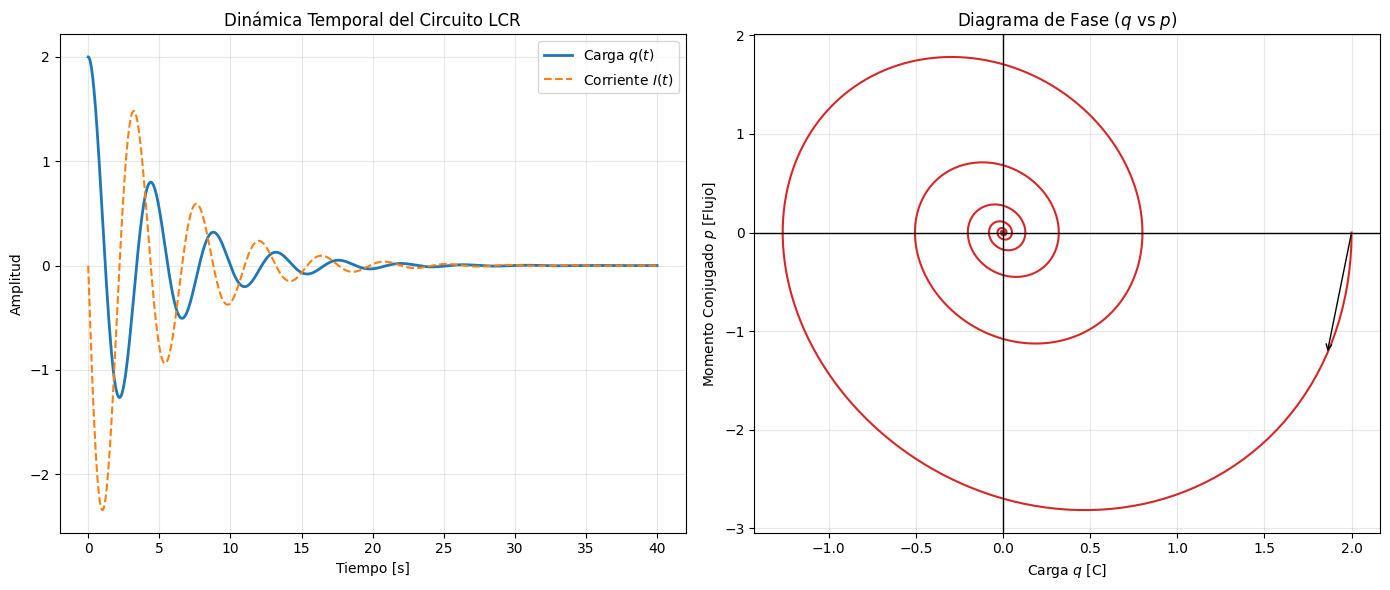

### Figura 1: Dinámica Temporal y Diagrama de Fase del Circuito LCR

Este gráfico muestra la evolución temporal de la carga $q(t)$ y la corriente $I(t)$ en un circuito LCR, evidenciando un comportamiento de oscilador amortiguado. El diagrama de fase $q$ vs $p$ ilustra la trayectoria en espiral que converge al origen debido a la disipación de la resistencia.

In [5]:
# --- Graficación de resultados ---
plt.figure(figsize=(14, 6))

# Subplot 1: evolución temporal de carga y corriente
plt.subplot(1, 2, 1)
plt.plot(t, q_t, label='Carga $q(t)$', color='#1f77b4', lw=2)
plt.plot(t, p_t / L, label='Corriente $I(t)$', color='#ff7f0e', linestyle='--')
plt.title('Dinámica Temporal del Circuito LCR', fontsize=12)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2: diagrama de fase (carga vs momento conjugado)
plt.subplot(1, 2, 2)
plt.plot(q_t, p_t, color='#d62728', lw=1.5)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title('Diagrama de Fase ($q$ vs $p$)', fontsize=12)
plt.xlabel('Carga $q$ [C]')
plt.ylabel('Momento Conjugado $p$ [Flujo]')
plt.grid(alpha=0.3)

# Flecha que indica el sentido de recorrido de la trayectoria en el espacio de fases
plt.annotate('', xy=(q_t[10], p_t[10]), xytext=(q_t[0], p_t[0]),
             arrowprops=dict(arrowstyle="->", color='black'))

plt.tight_layout()
plt.show()

display(Markdown(
    '### Figura 1: Dinámica Temporal y Diagrama de Fase del Circuito LCR\n\n'
    'Este gráfico muestra la evolución temporal de la carga $q(t)$ y la corriente $I(t)$ '
    'en un circuito LCR, evidenciando un comportamiento de oscilador amortiguado. El '
    'diagrama de fase $q$ vs $p$ ilustra la trayectoria en espiral que converge al origen '
    'debido a la disipación de la resistencia.'
))


# Análisis de resultados

La simulación permite interpretar la dinámica del circuito LCR desde la perspectiva del formalismo canónico.

En la dinámica temporal, tanto la corriente $I(t)$ como la carga $q(t)$ oscilan con una amplitud que decae exponencialmente, confirmando que el circuito se comporta como un oscilador armónico amortiguado. Es notable que cuando el capacitor alcanza su carga máxima la corriente es cero, lo que refleja el traspaso continuo de energía entre el campo eléctrico del capacitor y el campo magnético del inductor.

El diagrama de fase ($q$ vs $p$) es quizás la herramienta más informativa de este formalismo, porque muestra el comportamiento global del sistema en lugar de una sola variable en el tiempo. La trayectoria no se cierra sobre sí misma, como ocurriría en un circuito LC ideal sin resistencia, sino que se enrolla en espiral hacia el origen: la función de Rayleigh modela precisamente esa pérdida continua de energía por efecto de la resistencia. El origen actúa como un atractor del sistema, es decir, el estado de reposo en el que no queda carga almacenada ni flujo magnético residual.

Frente a las leyes de Kirchhoff, el método hamiltoniano ofrece una perspectiva geométrica y energética en lugar de una descripción empírica y local de voltajes y corrientes. Con Kirchhoff se resuelve una ecuación diferencial de segundo orden para una sola función; con Hamilton se describe el circuito como un flujo en el espacio de fases, lo que permite estudiar directamente la estabilidad y la conservación de energía sin necesitar la solución analítica explícita.

# Una aplicación a la mecánica cuántica: la juntura de Josephson

La juntura de Josephson es un paso natural para explorar la cuantización de circuitos. En este dispositivo, dos superconductores están separados por una barrera aislante lo bastante delgada como para permitir el efecto túnel de pares de Cooper (Josephson, 1962).

### El salto al potencial no lineal

A diferencia del capacitor convencional, cuya energía potencial es cuadrática ($U = \tfrac12 q^2/C$), en una juntura de Josephson la energía potencial depende del coseno de la diferencia de fase cuántica $\phi$ entre los dos superconductores:

$$U(\phi) = -E_J \cos(\phi)$$

donde $E_J$ es la energía de Josephson (Barone & Paternò, 1982). Bajo el formalismo hamiltoniano, este sistema se comporta como un péndulo simple, donde $\phi$ hace las veces de la coordenada generalizada y la "corriente" queda asociada a la derivada temporal de la fase.

Esta analogía es la base del diseño de los qubits superconductores modernos, como el transmon (Koch et al., 2007). A diferencia de un oscilador armónico simple, el potencial anarmónico de la juntura permite aislar sus dos primeros niveles de energía y usarlos como los estados $|0\rangle$ y $|1\rangle$ de un qubit.

## Comparación de potenciales: capacitor clásico vs juntura de Josephson

Este cálculo evalúa dos funciones sobre una malla de 500 puntos de fase, una operación ya vectorizada con NumPy. No se aplicó Numba aquí a propósito: con solo 500 puntos y una operación puramente vectorial, el tiempo de compilación de Numba superaría cualquier ganancia en tiempo de ejecución. Acelerar este cálculo sería optimizar "por defecto" en lugar de "con criterio".

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown

# Malla de fases / carga generalizada
phi = np.linspace(-2 * np.pi, 2 * np.pi, 500)

# Potencial del capacitor: cuadrático, propio de un oscilador armónico
U_cap = 0.5 * phi**2

# Potencial de la juntura de Josephson: cosenoidal, propio de un oscilador anarmónico.
# Se fija Ej = 1 para que coincida con el coeficiente cuadrático de U_cap: al expandir
# -Ej*cos(phi) en serie de Taylor alrededor de phi = 0, el término de segundo orden es
# (Ej/2)*phi^2, igual al de U_cap. Ambos potenciales comparten así la misma curvatura
# en el origen y solo difieren en los términos de orden superior, que son precisamente
# la anarmonicidad que hace útil a la juntura de Josephson para definir un qubit.
Ej = 1.0
U_jos = -Ej * np.cos(phi)


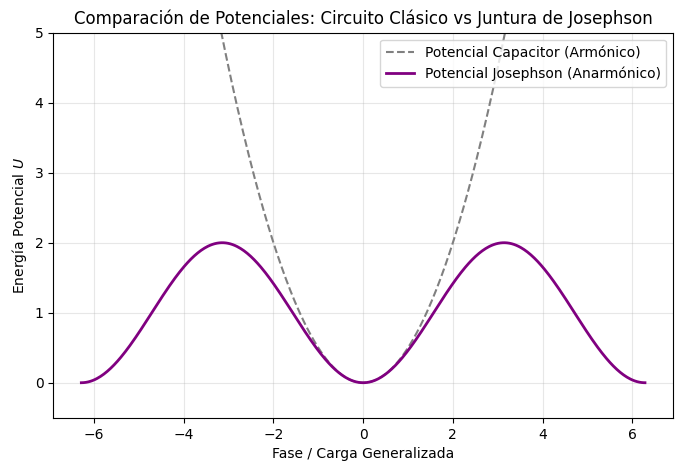

### Figura 2: Comparación de Potenciales: Circuito Clásico vs Juntura de Josephson

Esta figura compara el potencial cuadrático de un capacitor clásico (oscilador armónico) con el potencial cosenoidal de una juntura de Josephson (oscilador anarmónico). Cerca de phi = 0 ambos pozos son indistinguibles porque comparten la misma curvatura; la diferencia crece con la amplitud, y es precisamente esa anarmonicidad la que permite aislar los dos primeros niveles de energía de la juntura para usarlos como qubit.

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(phi, U_cap, '--', label='Potencial Capacitor (Armónico)', color='gray')

# Se desplaza U_jos verticalmente en +Ej para que ambos potenciales compartan el mismo
# mínimo (U = 0 en phi = 0); la comparación visual aísla así la diferencia de forma
# entre el pozo cuadrático y el pozo cosenoidal, en vez de una diferencia trivial de
# energía de referencia.
plt.plot(phi, U_jos + Ej, label='Potencial Josephson (Anarmónico)', color='purple', lw=2)

plt.title('Comparación de Potenciales: Circuito Clásico vs Juntura de Josephson')
plt.xlabel('Fase / Carga Generalizada')
plt.ylabel('Energía Potencial $U$')
plt.ylim(-0.5, 5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

display(Markdown(
    '### Figura 2: Comparación de Potenciales: Circuito Clásico vs Juntura de Josephson\n\n'
    'Esta figura compara el potencial cuadrático de un capacitor clásico (oscilador armónico) '
    'con el potencial cosenoidal de una juntura de Josephson (oscilador anarmónico). Cerca de '
    'phi = 0 ambos pozos son indistinguibles porque comparten la misma curvatura; la diferencia '
    'crece con la amplitud, y es precisamente esa anarmonicidad la que permite aislar los dos '
    'primeros niveles de energía de la juntura para usarlos como qubit.'
))


# Conclusiones

A través de analogías directas entre inductancia y masa, y entre carga y posición, se mostró que sistemas no mecánicos como los circuitos eléctricos pueden describirse por completo con las formulaciones lagrangiana y hamiltoniana (Goldstein et al., 2001). Incorporar la función de Rayleigh permitió que el formalismo hamiltoniano, pensado originalmente para sistemas conservativos, representara con exactitud un circuito real con resistencia. Trabajar con las variables conjugadas $(q, p)$ facilita además la transición hacia sistemas más complejos, como los circuitos acoplados, donde las leyes de Kirchhoff se vuelven algebraicamente pesadas.

# Perspectivas y trabajo futuro

Este trabajo sienta las bases para explorar áreas de la física moderna donde el formalismo canónico es el lenguaje por defecto y no una opción alternativa. Como continuaciones naturales se sugiere:

* **Cuantización de circuitos**: promover las variables $p$ y $q$ del hamiltoniano construido, $H = p^2/2L + q^2/2C$, a operadores que satisfagan la relación de conmutación canónica $[\hat q, \hat p] = i\hbar$ (Devoret, 1997).
* **Junturas de Josephson**: profundizar en circuitos superconductores donde el potencial es sinusoidal en lugar de cuadrático, lo que introduce no linealidades relevantes para fenómenos cuánticos (Barone & Paternò, 1982).
* **Circuitos acoplados**: extender el análisis a sistemas de varias mallas, para examinar cómo el formalismo de Euler-Lagrange maneja simultáneamente múltiples coordenadas generalizadas.

## Derivaciones detalladas: lagrangiano y transformada de Legendre

### 1) Euler-Lagrange para el circuito LC

Con $q(t)$ como carga generalizada del capacitor y lagrangiano

$$\mathcal{L} = \frac{1}{2}L\dot{q}^2 - \frac{1}{2C}q^2,$$

la ecuación de Euler-Lagrange es

$$\frac{d}{dt}\left(\frac{\partial\mathcal{L}}{\partial\dot{q}}\right) - \frac{\partial\mathcal{L}}{\partial q} = 0.$$

Calculando cada término,

$$\frac{\partial\mathcal{L}}{\partial\dot{q}} = L\dot{q}, \quad \frac{d}{dt}(L\dot{q}) = L\ddot{q}, \quad \frac{\partial\mathcal{L}}{\partial q} = -\frac{q}{C},$$

y sustituyendo se obtiene

$$L\ddot{q} + \frac{q}{C} = 0 \quad\Longrightarrow\quad \ddot{q} + \frac{1}{LC}q = 0,$$

la ecuación característica del oscilador eléctrico LC, de la misma forma que la del sistema masa-resorte.

### 2) Transformada de Legendre y hamiltoniano

El momento conjugado es $p = \partial\mathcal{L}/\partial\dot{q} = L\dot{q}$, de modo que $\dot q = p/L$ y la corriente es $I = \dot q = p/L$. La transformada de Legendre da

$$H(q,p) = p\dot{q} - \mathcal{L} = p\left(\frac{p}{L}\right) - \left[\frac{1}{2}L\left(\frac{p}{L}\right)^2 - \frac{1}{2C}q^2\right] = \frac{p^2}{2L} + \frac{q^2}{2C}.$$

### 3) Energía y disipación con la función de Rayleigh

Al añadir la resistencia $R$ mediante la función de Rayleigh $\mathcal{F} = \tfrac12 R\dot{q}^2$, los términos disipativos entran en la ecuación de Euler-Lagrange como

$$\frac{d}{dt}\left(\frac{\partial\mathcal{L}}{\partial\dot{q}}\right) - \frac{\partial\mathcal{L}}{\partial q} = -\frac{\partial\mathcal{F}}{\partial\dot{q}} = -R\dot{q},$$

lo que produce la ecuación del circuito RLC

$$L\ddot{q} + R\dot{q} + \frac{1}{C}q = 0.$$

La variación temporal del hamiltoniano, que en este caso ya no se conserva, queda relacionada directamente con la disipación:

$$\dot H = -R\dot{q}^2 = -RI^2.$$

### 4) Clasificación del amortiguamiento

La ecuación característica asociada es $Lr^2 + Rr + 1/C = 0$, con discriminante $\Delta = R^2 - 4L/C$. Según su signo, el circuito es:

- **Subamortiguado** si $\Delta < 0$ (soluciones oscilatorias amortiguadas).
- **Críticamente amortiguado** si $\Delta = 0$.
- **Sobreamortiguado** si $\Delta > 0$ (sin oscilación).

En términos del factor de amortiguamiento normalizado $\zeta = \tfrac{R}{2}\sqrt{C/L}$, la condición crítica corresponde a $\zeta = 1$.

---

## Nota sobre el uso del formalismo hamiltoniano con disipación

El formalismo hamiltoniano canónico asume, en su forma estándar, sistemas conservativos. Cuando hay disipación, introducir la función de Rayleigh es una solución práctica para deducir las ecuaciones de movimiento, pero el hamiltoniano resultante ya no se conserva y no constituye una cantidad conservada en sentido estricto. Existen formulaciones más formales para sistemas disipativos, entre ellas el hamiltoniano de Caldirola-Kanai, que introduce una dependencia temporal explícita en el propio hamiltoniano (Caldirola, 1941; Kanai, 1948); los sistemas hamiltonianos de contacto, que generalizan la geometría simpléctica para incluir disipación de forma geométrica (Bravetti, 2017); y el acoplamiento a un reservorio mediante el modelo de Caldeira-Leggett, útil para estudiar decoherencia y cuantización de sistemas disipativos (Caldeira & Leggett, 1983). Estas tres referencias se incluyen como lectura adicional en la bibliografía.

## Verificación independiente: circuito RLC en unidades SI con `solve_ivp`

Como segunda comprobación de la física ya desarrollada, esta sección integra la misma ecuación del circuito RLC ($L\ddot q + R\dot q + q/C = 0$, ver derivación en la sección anterior) pero de dos formas distintas de la simulación canónica de más arriba: directamente como ecuación de segundo orden en $q$, con `solve_ivp` (método adaptativo Runge-Kutta 4(5), Virtanen et al., 2020) en lugar de `odeint` (método LSODA), y con parámetros en unidades SI en vez de unidades arbitrarias. Usar un integrador y unas unidades distintas de las de la simulación canónica sirve como validación cruzada: si ambas simulaciones son consistentes con la misma física, es una señal de que no hay errores específicos de un método o de una escala de parámetros.

Las figuras se guardan en una carpeta relativa al notebook (`./figs_rlc`), creada automáticamente si no existe, para que el código funcione en cualquier entorno sin modificaciones.


In [8]:
# --- Parámetros del circuito RLC en unidades SI ---
L = 1e-3   # henry
C = 1e-6   # farad
R = 5.0    # ohm


In [9]:
@njit(cache=True)
def rlc_rhs(t, y, L, C, R):
    """
    Lado derecho de la ecuación de segundo orden del circuito RLC, escrita como
    un sistema de primer orden y = (q, dq/dt) para solve_ivp: f(t, y, *args).

    L*q'' + R*q' + q/C = 0  =>  q'' = -(R/L)*q' - (1/(L*C))*q

    Al igual que en la sección anterior, esta es una recurrencia temporal
    (el nuevo estado depende del estado inmediatamente anterior), así que se
    compila secuencialmente con Numba y NO se paraleliza.
    """
    q, dq = y
    ddq = -(R / L) * dq - (1.0 / (L * C)) * q
    return np.array([dq, ddq])


In [10]:
from scipy.integrate import solve_ivp

# --- Condiciones iniciales y ventana temporal ---
q0 = 1e-6  # carga inicial, en coulombs
I0 = 0.0   # corriente inicial, en amperes (dq/dt)
y0 = [q0, I0]

# La envolvente de decaimiento tiene constante de tiempo 2L/R = 4e-4 s. Una ventana
# de 0.003 s cubre unas 7-8 constantes de tiempo (~15 periodos de oscilación), lo
# suficiente para mostrar el transiente completo sin una cola plana ya extinguida.
t_span = (0.0, 0.003)
t_eval = np.linspace(t_span[0], t_span[1], 2000)

# rtol/atol se fijan explícitamente y por debajo de la tolerancia por defecto de
# solve_ivp porque las escalas SI (microcoulombs, milihenrios) son mucho más
# pequeñas que las unidades arbitrarias de la simulación anterior.
sol = solve_ivp(rlc_rhs, t_span, y0, args=(L, C, R), t_eval=t_eval, rtol=1e-8, atol=1e-10)

t = sol.t
q = sol.y[0]
dq = sol.y[1]
I = dq            # la corriente es la derivada de la carga
p = L * I         # momento conjugado, para comparar con la sección canónica


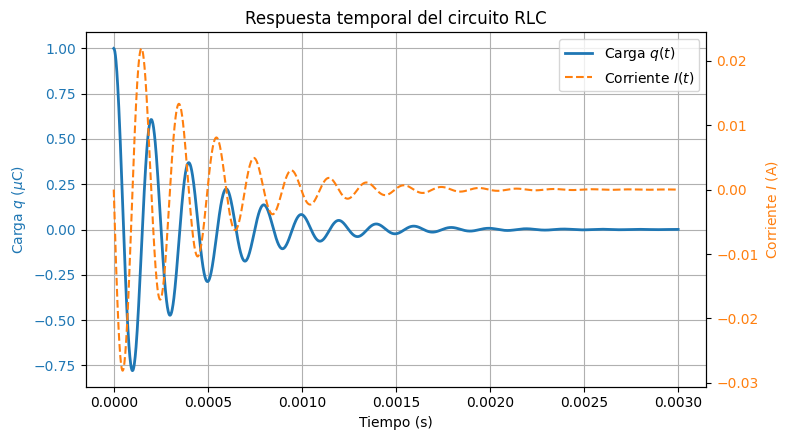

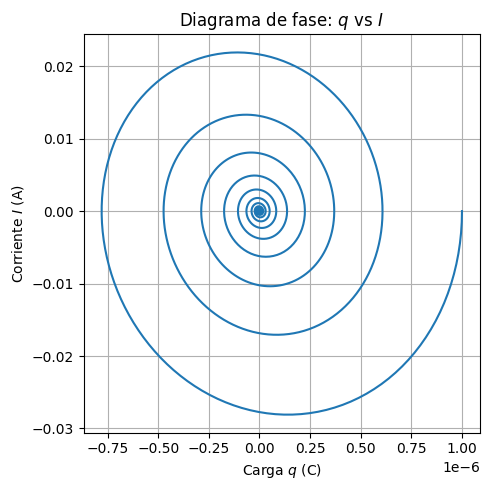

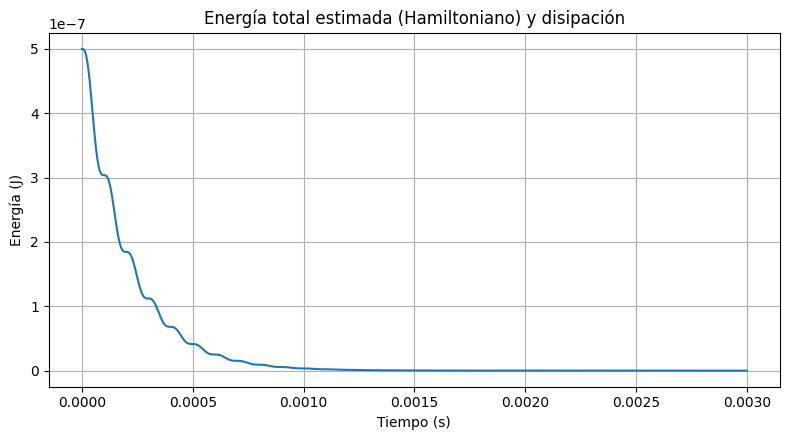

Figuras guardadas en: /content/figs_rlc


In [11]:
import os

# Carpeta de salida relativa al notebook (portable entre entornos)
outdir = "figs_rlc"
os.makedirs(outdir, exist_ok=True)

# Figura 1: q(t) e I(t). En unidades SI ambas magnitudes difieren en varios
# ordenes de magnitud (microcoulombs frente a amperes), asi que se usan dos
# ejes verticales independientes; de lo contrario, q(t) resultaria invisible
# junto a I(t) en un unico eje lineal compartido.
fig, ax_q = plt.subplots(figsize=(8, 4.5))
color_q, color_I = '#1f77b4', '#ff7f0e'

ax_q.plot(t, q * 1e6, color=color_q, lw=2, label='Carga $q(t)$')
ax_q.set_xlabel('Tiempo (s)')
ax_q.set_ylabel(r'Carga $q$ ($\mu$C)', color=color_q)
ax_q.tick_params(axis='y', labelcolor=color_q)
ax_q.grid(True)

ax_I = ax_q.twinx()
ax_I.plot(t, I, color=color_I, lw=1.5, linestyle='--', label='Corriente $I(t)$')
ax_I.set_ylabel('Corriente $I$ (A)', color=color_I)
ax_I.tick_params(axis='y', labelcolor=color_I)

lineas_q, etiquetas_q = ax_q.get_legend_handles_labels()
lineas_I, etiquetas_I = ax_I.get_legend_handles_labels()
ax_q.legend(lineas_q + lineas_I, etiquetas_q + etiquetas_I, loc='upper right')

plt.title('Respuesta temporal del circuito RLC')
plt.tight_layout()
plt.savefig(os.path.join(outdir, "rlc_q_I.png"), dpi=200)
plt.show()

# Figura 2: diagrama de fase q vs I. Aqui cada eje conserva su propia escala
# automatica, asi que la diferencia de ordenes de magnitud entre q e I no
# afecta la legibilidad de la trayectoria en espiral.
plt.figure(figsize=(5, 5))
plt.plot(q, I)
plt.xlabel('Carga $q$ (C)')
plt.ylabel('Corriente $I$ (A)')
plt.title('Diagrama de fase: $q$ vs $I$')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(outdir, "rlc_phase_qI.png"), dpi=200)
plt.show()

# Figura 3: energia total (hamiltoniano estimado) y su decaimiento
H = 0.5 * L * I**2 + 0.5 * q**2 / C
plt.figure(figsize=(8, 4.5))
plt.plot(t, H)
plt.xlabel('Tiempo (s)')
plt.ylabel('Energía (J)')
plt.title('Energía total estimada (Hamiltoniano) y disipación')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(outdir, "rlc_energy.png"), dpi=200)
plt.show()

print(f"Figuras guardadas en: {os.path.abspath(outdir)}")


---

# Referencias bibliográficas

Todas las referencias listadas a continuación se citan en el cuerpo del notebook; se verificaron autor, año, editorial y DOI de cada una contra su fuente original.

### Fuentes académicas primarias

Barone, A., & Paternò, G. (1982). *Physics and applications of the Josephson effect*. Wiley.

Bravetti, A. (2017). Contact Hamiltonian dynamics: The concept and its use. *Entropy*, *19*(10), 535. https://doi.org/10.3390/e19100535

Caldeira, A. O., & Leggett, A. J. (1983). Path integral approach to quantum Brownian motion. *Physica A: Statistical Mechanics and Its Applications*, *121*(3), 587–616. https://doi.org/10.1016/0378-4371(83)90013-4

Caldirola, P. (1941). Forze non conservative nella meccanica quantistica. *Il Nuovo Cimento*, *18*, 393–400. https://doi.org/10.1007/BF02960144

Devoret, M. H. (1997). Quantum fluctuations in electrical circuits. In S. Reynaud, E. Giacobino, & J. Zinn-Justin (Eds.), *Quantum fluctuations: Les Houches Session LXIII* (pp. 351–386). Elsevier.

Goldstein, H., Poole, C. P., & Safko, J. L. (2001). *Classical mechanics* (3rd ed.). Addison-Wesley.

Josephson, B. D. (1962). Possible new effects in superconductive tunnelling. *Physics Letters*, *1*(7), 251–253. https://doi.org/10.1016/0031-9163(62)91369-0

Kanai, E. (1948). On the quantization of the dissipative systems. *Progress of Theoretical Physics*, *3*(4), 440–442. https://doi.org/10.1143/ptp/3.4.440

Koch, J., Yu, T. M., Gambetta, J., Houck, A. A., Schuster, D. I., Majer, J., Blais, A., Devoret, M. H., Girvin, S. M., & Schoelkopf, R. J. (2007). Charge-insensitive qubit design derived from the Cooper pair box. *Physical Review A*, *76*(4), 042319. https://doi.org/10.1103/PhysRevA.76.042319

Lam, S. K., Pitrou, A., & Seibert, S. (2015). Numba: A LLVM-based Python JIT compiler. In *Proceedings of the Second Workshop on the LLVM Compiler Infrastructure in HPC* (Article 7). ACM. https://doi.org/10.1145/2833157.2833162

Thornton, S. T., & Marion, J. B. (2003). *Classical dynamics of particles and systems* (5th ed.). Brooks/Cole.

Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., ... SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods*, *17*(3), 261–272. https://doi.org/10.1038/s41592-019-0686-2

### Recursos complementarios

Girvin, S. M. (2021, 6 de mayo). *A brief history of superconducting qubits* [Conferencia magistral, QC40: Physics of Computation Conference, MIT Endicott House]. https://www.youtube.com/watch?v=xjlGL4Mvq7A
